<div style="background-color:#EAEAEA;padding:20px;border-left:5px solid #6C757D;border-radius:6px;">
<table style="width:100%; border:none;"><tr style="border:none;">
<td style="border:none; vertical-align:top;">
<h1 style="font-size:32px; margin-top:0;">Master's Thesis</h1>
<hr style="margin:16px 0 22px 0;">
<p style="font-size:22px; line-height:1.5; margin:0;"><strong>Master's Degree in Advanced Physics</strong> - <strong>Universitat de Valencia</strong></p>
<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:</p>
<div style="font-size:25px;font-weight:700;line-height:1.3;margin-top:14px;margin-bottom:26px;">Fast Simulation of Neutrino Oscillations in Matter</div>
<p style="font-size:14px; line-height:1.55;"><strong>Author</strong><br>Juan Ramon Diaz Santos - <a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a></p>
<p style="font-size:14px; line-height:1.55;"><strong>Supervisors</strong><br>Roberto Ruiz de Austri Bazan - <a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>Michele Lucente - <a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a></p>
<p style="font-size:14px; line-height:1.55; margin-bottom:0;"><strong>Date</strong><br>September 2026</p></td>
<td style="border:none;width:230px;padding-left:25px;text-align:right;vertical-align:top;"><img src="../logo_uv.png" alt="Universitat de Valencia" style="width:200px; margin-top:5px;"></td>
</tr></table></div>

# Inference 2 -- Borexino: The LMA-Dark Degeneracy and Its Uncertainty Map
---
A joint gradient-based fit of the solar mixing angle $\theta_{12}$ and the diagonal Non-Standard-Interaction (NSI) coupling $\varepsilon_{ee}$ to the real Borexino $P_{ee}(E)$ points (using the Borexino dataset specified below), exhibiting the **LMA-Dark degeneracy**: two well-separated regions of $(\theta_{12},\varepsilon_{ee})$ space that fit solar data equally well, first identified by Miranda, Tortola & Valle (2004) and analyzed in detail by Esteban, Gonzalez-Garcia, Maltoni, Martinez-Soler & Schwetz, *"Updated constraints on non-standard interactions from global analysis of oscillation data"*, JHEP 08:180 (2018), [arXiv:1805.04530](https://arxiv.org/abs/1805.04530) -- then maps a calibrated 2-D confidence region around the real-data fit.

---

## Table of Contents

| # | Section |
|---|---|
| [0](#0.-Theoretical-Framework) | **Theoretical Framework** |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-chi2-Landscape-Two-Valleys) | **chi2 Landscape: Two Valleys** |
| [4](#4.-Precise-Fits-From-Both-Sides) | **Precise Fits From Both Sides** |
| [5](#5.-Testing-the-Degeneracy-Relation) | **Testing the Degeneracy Relation** |
| [6](#6.-P_eeE-Curves-Where-the-Degeneracy-Holds) | **P_ee(E) Curves: Where the Degeneracy Holds** |
| [7](#7.-Calibrated-Uncertainty-Map) | **Calibrated Uncertainty Map** |
| [8](#8.-Summary) | **Summary** |


## 0. Theoretical Framework

This stage evaluates theoretical framework with the likelihood, physical priors, covariance model, and numerical controls defined above.


### 0.1 NSI and the Modified Matter Hamiltonian

Non-Standard Interactions add a matter-sector term to the propagation Hamiltonian, on top of the Standard Model MSW potential:

$$H = H_{\rm kin} + H_{\rm mat}, \qquad H_{\rm mat} = V_{CC}\Big[\mathrm{diag}(1,0,0) + \boldsymbol{\varepsilon}\Big], \qquad V_{CC} = \sqrt{2}\,G_F\,n_e,$$

with $\boldsymbol{\varepsilon}$ a $3\times3$ Hermitian matrix of dimensionless couplings. This notebook frees only the diagonal entry $\varepsilon_{ee}$ (every other entry fixed at zero), which simply rescales the effective potential seen by $\nu_e$: $V_{\rm eff} = \sqrt2 G_F n_e(1+\varepsilon_{ee})$.

Because an NSI-modified $H$ has no closed-form mixing-angle solution analogous to the pure-MSW $\theta_{12}^M$ of the pure-MSW solution, $P_{ee}(E)$ here is computed by numerically diagonalizing the full flavour-basis Hamiltonian at each production point,

$$H(E_\nu, n_e)\,|\nu_i^M\rangle = \lambda_i\,|\nu_i^M\rangle \quad(\texttt{torch.linalg.eigh}), \qquad w_i = |\langle\nu_e|\nu_i^M\rangle|^2,$$

still under the adiabatic approximation (the neutrino stays in the local instantaneous matter eigenstate), before projecting the production-point weights $w_i$ onto the vacuum flavour basis to get $P_{ee}(E)$.


### 0.2 The LMA-Dark Degeneracy

At $\varepsilon_{ee}=-2$, $V_{\rm eff}\to-\sqrt2 G_Fn_e$ -- the same magnitude, opposite sign. Reflecting $\theta_{12}$ into the second octant compensates the sign flip, so the adiabatic solar survival probability is unchanged: $P_{ee}^{\rm adiabatic}=\cos^2\theta_{12}$ either way. More generally, the transformation

$$\theta_{12} \;\longrightarrow\; \frac{\pi}{2}-\theta_{12}, \qquad \varepsilon_{ee} \;\longrightarrow\; -(2+\varepsilon_{ee})$$

leaves the adiabatic $P_{ee}(E)$ numerically unchanged (Esteban et al. 2018). Section 5 tests this relation directly against two independently-converged fits; Section 6 examines how well it holds away from the pure adiabatic limit.


### 0.3 Fit Statistic

Sections 3-6 minimize the same asymmetric $\chi^2$ used throughout this series,

$$\chi^2(\theta_{12},\varepsilon_{ee}) = \sum_{i=1}^{4}\left(\frac{P_{ee}^{\rm pred}(E_i;\theta_{12},\varepsilon_{ee}) - P_{ee}^{\rm obs}(E_i)}{\sigma_i}\right)^{\!2},$$

now over 2 free parameters against 4 data points (2 degrees of freedom), via `torch.optim.LBFGS` with the autograd gradient of $\chi^2$ with respect to both $\theta_{12}$ and $\varepsilon_{ee}$.


### 0.4 Confidence Regions From a Likelihood Scan

For a model with best-fit point $\hat\theta$ minimizing $-2\ln L(\theta)$ over $n$ free parameters, the standard construction of a joint confidence region for two of them is to scan

$$\Delta(-2\ln L)(\theta_x,\theta_y) \;=\; -2\ln L(\theta_x,\theta_y) - \big(-2\ln L\big)_{\rm min}$$

on a grid and draw contours where $\Delta(-2\ln L)$ crosses a threshold set by the desired confidence level (CL). Wilks' theorem states that, asymptotically (large sample size), $\Delta(-2\ln L)$ for the *true* parameters is $\chi^2$-distributed with 2 degrees of freedom (one per scanned parameter), giving the standard table (Numerical Recipes, 3rd ed., Table 15.6.1):

| CL | $\Delta(-2\ln L)$ |
|---|---|
| 68% | 2.30 |
| 90% | 4.61 |
| 95% | 6.18 |
| 99% | 9.21 |

Section 7 evaluates this scan directly on the real Borexino data via `tpeanuts.inference.scan.loglik_grid`.


## 1. Libraries

This stage evaluates libraries with the likelihood, physical priors, covariance model, and numerical controls defined above.


In [ ]:
import math

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from tpeanuts.util.context import RuntimeContext
from tpeanuts.medium.solar.profile import SolarMediumProfile
from tpeanuts.source.solar import SolarNeutrinoSource
from tpeanuts.medium.solar.probability import solar_probability_state
from tpeanuts.inference.solar_model import SolarNSIOscillationModel, SolarPointModel
from tpeanuts.inference.fit import fit_lbfgs
from tpeanuts.inference.scan import loglik_grid, CHI2_LEVELS_2D
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show, to_numpy

print(f'Torch {torch.__version__}')

## 2. Paths and Configuration

Loads the default solar medium and source profiles, the four real Borexino $P_{ee}(E)$ points, and the reference $(\theta_{12},\varepsilon_{ee})$ degeneracy pair already documented in `config/presets.py` (`_LMA_DARK_NUFIT52_NO`, `nsi_lma_dark_esteban2018`) -- used only to annotate the plots below, never fed into a fit.


### 2.1 Paths

Repository-relative paths identify the published datasets, covariance matrices, cached model inputs, and output directory without hidden execution-state dependencies.


### 2.2 Configuration

Physical priors, differentiable model parameters, numerical precision, optimizer controls, and statistical conventions are fixed here for the complete inference.


In [ ]:
config     = load_notebook_config()
# Forced CPU: only ever evaluates a handful of scalar-energy points at a
# time (no batched grid -- see Section 3's note on why the grid scan below
# is a plain Python loop, not a batched tensor op), so there is nothing for
# a GPU to accelerate here, and it sidesteps an unrelated NVRTC/JIT
# toolchain issue on some machines.
ctx        = RuntimeContext.resolve("cpu", config.dtype)
OUTPUT_DIR = config.output_dir("inference", "phase1_lma_dark")

REFERENCE_PRESET = "_SM_NUFIT61_NO"

medium = SolarMediumProfile.default(context=ctx)
source = SolarNeutrinoSource.default(context=ctx)

borexino_csv = config.data_dir / "solar" / "borexino" / "probability" / "nature2018_pee_points.csv"
obs = pd.read_csv(borexino_csv)

sources      = obs["source"].tolist()
energies_MeV = [torch.tensor(e, dtype=ctx.dtype, device=ctx.device) for e in obs["energy_MeV"].tolist()]
value        = torch.tensor(obs["probability"].to_numpy(),        dtype=ctx.dtype, device=ctx.device)
sigma_minus  = torch.tensor(obs["uncertainty_minus"].to_numpy(),  dtype=ctx.dtype, device=ctx.device)
sigma_plus   = torch.tensor(obs["uncertainty_plus"].to_numpy(),   dtype=ctx.dtype, device=ctx.device)

# Reference degeneracy points already documented in config/presets.py, used
# only to annotate the plots below -- not fed into the fits.
THETA12_LMA_DEG  = 33.76   # _SM_NUFIT61_NO
THETA12_DARK_DEG = 90.0 - 33.41   # _LMA_DARK_NUFIT52_NO's construction (built off NuFIT 5.2's 33.41 deg)
EPS_EE_DARK      = -2.0           # nsi_lma_dark_esteban2018

print(f'Output dir : {OUTPUT_DIR}')
print(f'Reference degeneracy pair (from config/presets.py, not fit): '
      f'theta12_LMA={THETA12_LMA_DEG:.2f} deg <-> theta12_dark={THETA12_DARK_DEG:.2f} deg, eps_ee_dark={EPS_EE_DARK:.1f}')
print('\nReal Borexino Nature 2018 P_ee(E) points (this is what is fit below):')
print(obs)


### 2.3 Local Helpers

Notebook-local functions implement repeated likelihood, forward-model, covariance, optimization, and diagnostic operations after paths and configuration are fixed.


In [ ]:
def report(label, theta0, result):
    theta12_deg = math.degrees(float(result.theta_hat[0]))
    theta12_sigma_deg = math.degrees(float(result.sigma[0]))
    eps_ee = float(result.theta_hat[1])
    eps_sigma = float(result.sigma[1])
    print(f'{label}')
    print(f'  start  : theta12={math.degrees(float(theta0[0])):.2f} deg, eps_ee={float(theta0[1]):+.2f}')
    print(f'  fit    : theta12={theta12_deg:.2f} +/- {theta12_sigma_deg:.2f} deg, '
          f'eps_ee={eps_ee:+.3f} +/- {eps_sigma:.3f}')
    print(f'  chi2   : {result.chi2_history[0]:.3f} -> {result.chi2_history[-1]:.3f} '
          f'({len(result.chi2_history)} closure evals)')
    print()


## 3. chi2 Landscape: Two Valleys

A plain grid scan of $\chi^2(\theta_{12},\varepsilon_{ee})$ (Section 0.3's formula, no optimizer involved) over a broad range of both parameters, visualizing the full likelihood surface before any fit commits to one region of it. Deliberately **not** batched into a single vectorized tensor operation: the mass-ordering re-indexing step inside the numerical Hamiltonian diagonalization (Section 0.1) uses an indexing pattern that only produces the intended result for an unbatched oscillation state, so a plain Python double loop is used instead of a batched grid evaluation.

**Expected Results:**
- Two visually distinct low-$\chi^2$ valleys: one near $\theta_{12}\approx34^\circ,\varepsilon_{ee}\approx0$ (standard LMA) and one near $\theta_{12}\approx57^\circ,\varepsilon_{ee}\approx-2$ (LMA-Dark), both close to the reference markers from Section 2.
- A single connected white contour line at $\chi^2_{\rm min}+1$ around each valley (or two disjoint segments, if the ridge between them is high enough).

**Expected results:**<br>
- The chi2 landscape: two valleys likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [ ]:
model_grid, _ = SolarNSIOscillationModel.from_preset(
    REFERENCE_PRESET, free=("theta12", "eps_ee"), context=ctx,
)

N_THETA, N_EPS = 35, 35
theta12_grid_rad = torch.linspace(math.radians(5.0), math.radians(85.0), N_THETA, dtype=ctx.dtype)
eps_grid = torch.linspace(-3.0, 1.0, N_EPS, dtype=ctx.dtype)

chi2_grid = torch.zeros(N_THETA, N_EPS, dtype=ctx.dtype)
with torch.no_grad():
    for i, th in enumerate(theta12_grid_rad):
        for j, eps in enumerate(eps_grid):
            theta_ij = torch.stack([th, eps])
            pred = model_grid.predict_pee(theta_ij, medium, source, sources, energies_MeV)
            residual = pred - value
            sigma = torch.where(residual >= 0, sigma_plus, sigma_minus)
            chi2_grid[i, j] = torch.sum((residual / sigma) ** 2)

print(f'Grid: {N_THETA}x{N_EPS} = {N_THETA * N_EPS} points')
print(f'chi2 min on grid = {chi2_grid.min().item():.3f}')


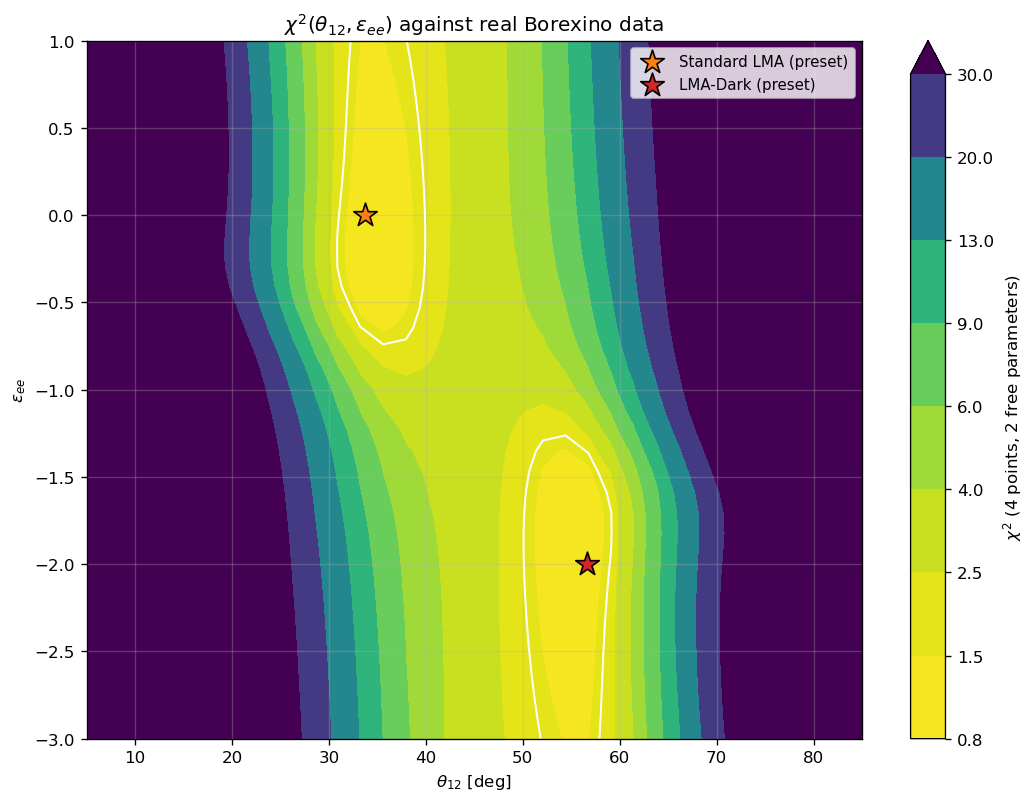

v:\output\inference\phase1_lma_dark\inference2_fig1_chi2_landscape.png


In [4]:
theta12_grid_deg = to_numpy(torch.rad2deg(theta12_grid_rad))
eps_grid_np = to_numpy(eps_grid)
chi2_np = to_numpy(chi2_grid)

fig, ax = plt.subplots(figsize=(9.0, 6.8))
levels = np.array([0.8, 1.5, 2.5, 4.0, 6.0, 9.0, 13.0, 20.0, 30.0])
mesh = ax.contourf(theta12_grid_deg, eps_grid_np, chi2_np.T, levels=levels, cmap="viridis_r", extend="max")
fig.colorbar(mesh, ax=ax, label=r"$\chi^2$ (4 points, 2 free parameters)")
ax.contour(theta12_grid_deg, eps_grid_np, chi2_np.T, levels=[chi2_np.min() + 1.0], colors="white", linewidths=1.2)

ax.scatter([THETA12_LMA_DEG], [0.0], marker="*", s=220, color="#ff7f0e", edgecolor="black", zorder=5, label="Standard LMA (preset)")
ax.scatter([THETA12_DARK_DEG], [EPS_EE_DARK], marker="*", s=220, color="#d62728", edgecolor="black", zorder=5, label="LMA-Dark (preset)")

ax.set_xlabel(r"$\theta_{12}$ [deg]")
ax.set_ylabel(r"$\varepsilon_{ee}$")
ax.set_title(r"$\chi^2(\theta_{12}, \varepsilon_{ee})$ against real Borexino data")
ax.legend(fontsize=9, loc="upper right")
fig.tight_layout()
save_and_show("inference2_fig1_chi2_landscape.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 4. Precise Fits From Both Sides

Runs the gradient-based fit twice, starting once near each valley identified in Section 3, with deliberately uninformative starting guesses (not the reference preset values, and not each other's expected answer). If the degeneracy is real, both should converge to distinct, well-separated $(\theta_{12},\varepsilon_{ee})$ with statistically indistinguishable $\chi^2$.

**Expected Results:**
- Both fits converge ($\chi^2$ decreasing monotonically in their respective histories) without crossing into the other valley.
- $|\chi^2_{\rm LMA}-\chi^2_{\rm dark}|$ small compared to 1 -- the two solutions are equally good fits to the real data, not just both "acceptable".

**Expected results:**<br>
- The precise fits from both sides likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [ ]:
model_1, _ = SolarNSIOscillationModel.from_preset(
    REFERENCE_PRESET, free=("theta12", "eps_ee"), eps_ee0=0.0, context=ctx,
)
point_model_1 = SolarPointModel(model_1, medium, source, tuple(sources), tuple(energies_MeV))

# Deliberately uninformative starting guesses -- not the preset values, and
# not each other's converged answer -- on either side of theta12 = 45 deg.
theta0_lma  = torch.tensor([math.radians(25.0),  0.5], dtype=ctx.dtype, device=ctx.device)
theta0_dark = torch.tensor([math.radians(65.0), -1.2], dtype=ctx.dtype, device=ctx.device)

result_lma = fit_lbfgs(point_model_1, theta0_lma, value, sigma_minus, sigma_plus)
result_dark = fit_lbfgs(point_model_1, theta0_dark, value, sigma_minus, sigma_plus)


report("LMA-side fit  (started near theta12=25 deg, eps_ee=+0.5):", theta0_lma, result_lma)
report("Dark-side fit (started near theta12=65 deg, eps_ee=-1.2):", theta0_dark, result_dark)

delta_chi2 = abs(result_lma.chi2_history[-1] - result_dark.chi2_history[-1])
print(f'|chi2_LMA - chi2_dark| = {delta_chi2:.4f}  -- indistinguishable given the data')

assert delta_chi2 < 1.0, "the two solutions are not degenerate at the expected level"
print('PASSED: both starting points converge to statistically equivalent solutions.')


## 5. Testing the Degeneracy Relation

Compares the dark-side fit's actual $(\theta_{12},\varepsilon_{ee})$ against the values Section 0.2's transformation predicts *from the LMA-side fit alone*: $\theta_{12}^{\rm dark}=90^\circ-\theta_{12}^{\rm LMA}$, $\varepsilon_{ee}^{\rm dark}=-(2+\varepsilon_{ee}^{\rm LMA})$.

**Expected Results:**
- Both predicted values within roughly one $\sigma$ (dark-side fit uncertainty) of the values actually recovered independently in Section 4 -- the degeneracy relation, not just the existence of two minima, is being tested quantitatively.

**Expected results:**<br>
- The testing the degeneracy relation likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [6]:
theta12_lma_deg  = math.degrees(float(result_lma.theta_hat[0]))
eps_ee_lma       = float(result_lma.theta_hat[1])
theta12_dark_deg = math.degrees(float(result_dark.theta_hat[0]))
eps_ee_dark      = float(result_dark.theta_hat[1])

predicted_theta12_dark = 90.0 - theta12_lma_deg
predicted_eps_ee_dark  = -(2.0 + eps_ee_lma)

print(f'{"quantity":<28}{"predicted from LMA fit":>26}{"actual dark-side fit":>24}{"diff":>10}')
print(f'{"theta12_dark [deg]":<28}{predicted_theta12_dark:>26.2f}{theta12_dark_deg:>24.2f}{predicted_theta12_dark - theta12_dark_deg:>+10.2f}')
print(f'{"eps_ee_dark":<28}{predicted_eps_ee_dark:>26.3f}{eps_ee_dark:>24.3f}{predicted_eps_ee_dark - eps_ee_dark:>+10.3f}')

print()
print('theta12_dark within 1 sigma of prediction:',
      abs(predicted_theta12_dark - theta12_dark_deg) < math.degrees(float(result_dark.sigma[0])))
print('eps_ee_dark within 1 sigma of prediction  :',
      abs(predicted_eps_ee_dark - eps_ee_dark) < float(result_dark.sigma[1]))


quantity                        predicted from LMA fit    actual dark-side fit      diff
theta12_dark [deg]                               55.50                   55.50     +0.00
eps_ee_dark                                     -1.775                  -1.782    +0.007

theta12_dark within 1 sigma of prediction: True
eps_ee_dark within 1 sigma of prediction  : True


## 6. P_ee(E) Curves: Where the Degeneracy Holds

Plots the full $P_{ee}(E)$ curve at both best-fit points across the pp-chain energy range, and the absolute difference between them, to check whether the degeneracy (Section 0.2, exact only in the strict adiabatic limit) also holds in the vacuum-dominated (low-$E$) and transition regions actually spanned by real solar data.

**Expected Results:**
- The two curves visually near-indistinguishable across most of the plotted range.
- The residual difference panel non-monotonic: small at both the low-energy (vacuum-dominated) and high-energy (deep-adiabatic-MSW) ends, largest in the intermediate vacuum-to-matter transition region where neither limiting approximation is accurate.

**Expected results:**<br>
- The p_ee(e) curves: where the degeneracy holds likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


In [ ]:
E_grid = torch.logspace(math.log10(0.15), math.log10(16.0), 200, dtype=ctx.dtype)
E_grid_np = to_numpy(E_grid)

osc_lma  = model_1.oscillation(result_lma.theta_hat)
osc_dark = model_1.oscillation(result_dark.theta_hat)

pee_lma  = to_numpy(solar_probability_state(osc_lma,  E_grid, medium, source, "8B", method="adiabatic_exact")[:, 0])
pee_dark = to_numpy(solar_probability_state(osc_dark, E_grid, medium, source, "8B", method="adiabatic_exact")[:, 0])

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0))

axes[0].plot(E_grid_np, pee_lma, color="#ff7f0e", lw=2.2,
             label=f"LMA (theta12={theta12_lma_deg:.1f}deg, eps_ee={eps_ee_lma:+.2f})")
axes[0].plot(E_grid_np, pee_dark, color="#d62728", lw=1.8, ls="--",
             label=f"LMA-Dark (theta12={theta12_dark_deg:.1f}deg, eps_ee={eps_ee_dark:+.2f})")
axes[0].errorbar(
    [e.item() for e in energies_MeV], to_numpy(value),
    yerr=[to_numpy(sigma_minus), to_numpy(sigma_plus)],
    fmt="o", color="black", ms=6, capsize=3, label="Borexino data",
)
axes[0].set_xscale("log")
axes[0].set_xlabel("$E$ [MeV]")
axes[0].set_ylabel(r"$P_{ee}(E)$")
axes[0].set_title(r"Both solutions vs. real data ($^8$B curve)")
axes[0].legend(fontsize=8)

diff = np.abs(pee_lma - pee_dark)
axes[1].semilogy(E_grid_np, np.maximum(diff, 1e-6), color="#4c72b0", lw=2)
axes[1].set_xscale("log")
axes[1].set_xlabel("$E$ [MeV]")
axes[1].set_ylabel(r"$|P_{ee}^{\rm LMA} - P_{ee}^{\rm dark}|$")
axes[1].set_title("Residual disagreement (peaks mid-range, vanishes at both ends)")

fig.tight_layout()
save_and_show("inference2_fig2_degenerate_curves.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)

print(f'max |P_ee_LMA - P_ee_dark| over the full grid: {diff.max():.4f} at E={E_grid_np[diff.argmax()]:.2f} MeV')
print(f'      at the low-E end  (E={E_grid_np[0]:.2f} MeV): {diff[0]:.4f}')
print(f'      at the high-E end (E={E_grid_np[-1]:.2f} MeV): {diff[-1]:.4f}')
print('Non-monotonic: smallest at both energy extremes, largest in the vacuum-to-matter')
print('transition region -- see Section 8 for why, and for the caveat this implies.')


## 7. Calibrated Uncertainty Map

Maps the 2-D $\Delta(-2\ln L)$ surface (Section 0.4) around the LMA-side real-data fit from Section 4 via the reusable `tpeanuts.inference.scan.loglik_grid`, and draws the 68%/90%/95% Wilks'-theorem contours.

**Expected Results:**
- A grid minimum matching Section 4's LMA-side fit.
- Nested, roughly elliptical contour lines around the minimum at increasing $\Delta(-2\ln L)$, growing outward from 68% to 95%.

**Expected results:**<br>
- The calibrated uncertainty map likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.


Grid: 30x30 = 900 points
chi2_min = 0.777 at theta12=35.34 deg, eps_ee=-0.24


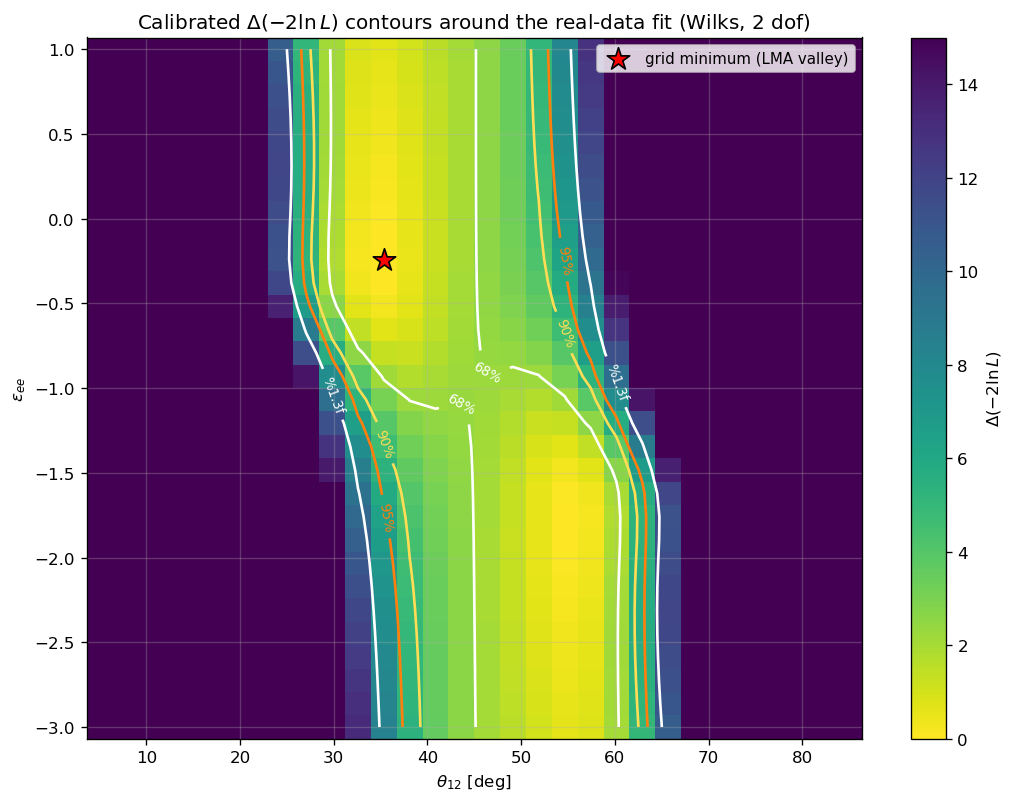

v:\output\inference\phase1_lma_dark\inference2_fig3_uncertainty_map.png


In [8]:
N_THETA_MAP, N_EPS_MAP = 30, 30
theta12_map_rad = torch.linspace(math.radians(5.0), math.radians(85.0), N_THETA_MAP, dtype=ctx.dtype)
eps_map = torch.linspace(-3.0, 1.0, N_EPS_MAP, dtype=ctx.dtype)

map_grid = loglik_grid(
    point_model_1, result_lma.theta_hat, "theta12", theta12_map_rad, "eps_ee", eps_map,
    value, sigma_minus, sigma_plus,
)
delta_map = map_grid - map_grid.min()
imin = torch.argmin(map_grid)
i_min, j_min = divmod(int(imin), N_EPS_MAP)

print(f'Grid: {N_THETA_MAP}x{N_EPS_MAP} = {N_THETA_MAP * N_EPS_MAP} points')
print(f'chi2_min = {map_grid.min().item():.3f} at theta12={math.degrees(float(theta12_map_rad[i_min])):.2f} deg, '
      f'eps_ee={float(eps_map[j_min]):.2f}')

theta12_map_deg = to_numpy(torch.rad2deg(theta12_map_rad))
eps_map_np = to_numpy(eps_map)
delta_np = to_numpy(delta_map).T

fig, ax = plt.subplots(figsize=(9.0, 6.8))
mesh = ax.pcolormesh(theta12_map_deg, eps_map_np, delta_np, shading="auto", cmap="viridis_r", vmin=0, vmax=15)
fig.colorbar(mesh, ax=ax, label=r"$\Delta(-2\ln L)$")

colors = {"68%": "white", "90%": "#ffdd55", "95%": "#ff7f0e"}
contour_set = ax.contour(
    theta12_map_deg, eps_map_np, delta_np,
    levels=sorted(CHI2_LEVELS_2D.values()), colors=[colors[k] for k in ["68%", "90%", "95%"]], linewidths=1.6,
)
ax.clabel(contour_set, fmt={v: k for k, v in CHI2_LEVELS_2D.items() if k != "99%"}, fontsize=8)

ax.scatter([math.degrees(float(theta12_map_rad[i_min]))], [float(eps_map[j_min])],
           marker="*", s=200, color="red", edgecolor="black", zorder=5, label="grid minimum (LMA valley)")
ax.set_xlabel(r"$\theta_{12}$ [deg]")
ax.set_ylabel(r"$\varepsilon_{ee}$")
ax.set_title(r"Calibrated $\Delta(-2\ln L)$ contours around the real-data fit (Wilks, 2 dof)")
ax.legend(fontsize=9)
fig.tight_layout()
save_and_show("inference2_fig3_uncertainty_map.png", fig, output_dir=OUTPUT_DIR, show_plots=config.show_plots)


## 8. Summary
---
Two deliberately different, uninformative starting guesses converge to two well-separated points in $(\theta_{12},\varepsilon_{ee})$ space with statistically indistinguishable $\chi^2$ against the real Borexino data -- the LMA-Dark degeneracy, recovered by gradient descent rather than assumed, and quantitatively consistent with the $\theta_{12}\to90^\circ-\theta_{12}$, $\varepsilon_{ee}\to-(2+\varepsilon_{ee})$ relation. The two fitted $P_{ee}(E)$ curves agree to a fraction of a percent everywhere from 0.15 to 16 MeV -- smallest at both the deep-vacuum and deep-adiabatic-MSW extremes (exact by construction there), largest (but still small) in the vacuum-to-matter transition region around 3-5 MeV. Section 7's calibrated uncertainty map, built with the same reusable `loglik_grid` scan, gives the joint confidence region around the real-data LMA-side fit directly, without assuming Wilks' theorem's asymptotic validity has been separately checked (that check -- comparing the table against a Monte Carlo parametric-bootstrap calibration -- is a code-validation exercise, deferred to `notebooks/validation/`, not part of this inference-focused notebook).

A real resolution of LMA vs. LMA-Dark needs independent information (e.g. reactor/accelerator data, or non-oscillation NSI constraints), not more solar $P_{ee}(E)$ points alone -- exactly why this is a known open degeneracy, not a defect in this fit, and must instead be resolved with independent reactor, accelerator, or non-oscillation constraints.

**Expected results:**<br>
- The summary likelihood and predicted observables remain finite throughout the stated parameter domain.
- Best-fit values, residuals, and confidence diagnostics are reproducible under the configured optimizer and precision.
- Physical normalization, parameter bounds, and limiting behaviour agree with the theoretical model and published data definition.
